goal: find an polynomial that fits the values the best

1. select degree (based on complexity of data)
2. fit the polynomial
3. evaluate fit



- try degree 1-3 first
- never use degree > (n-1), where n is the # of data points, will overfit
- look at underlying system, if it's known to be
    - linear: degree = 1
    - curve but no inflection: degree = 2
    - has inflection: degree = 3,4
- if you need higher than degree 10 to fit the data, try something else



In [1]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
# Step 1: Generate some sample data
# Creating data points that roughly follow a quadratic curve
np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise
plt.scatter(x,y)
plt.show()

<Figure size 640x480 with 1 Axes>

In [2]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 2 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Step 3: Use the coefficients to predict y-values (polynomial function)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
print(polynomial)

Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]
       2
2.092 x + 1.588 x + 0.6061


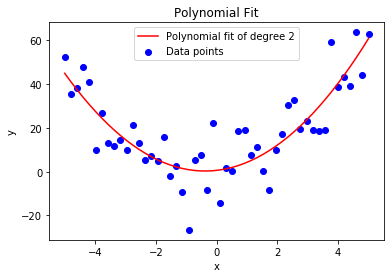

In [3]:
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)
# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [4]:
# Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 108.8860
R-squared: 0.7236


In [5]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data
degree = 8 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Step 3: Use the coefficients to predict y-values (polynomial function)

# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
print(polynomial)

Polynomial Coefficients:  [-2.59033259e-04 -8.59974375e-04  1.31843836e-02  3.81772193e-02
 -1.97269814e-01 -5.53382317e-01  2.88058132e+00  4.19720722e+00
  4.88986004e-01]
           8           7           6           5          4          3
-0.000259 x - 0.00086 x + 0.01318 x + 0.03818 x - 0.1973 x - 0.5534 x
          2
 + 2.881 x + 4.197 x + 0.489


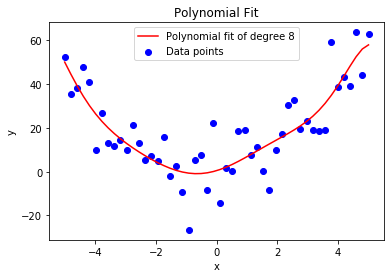

In [6]:
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)
# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

evaluatign fit: how well did our curve fit the data points?

MSE: mean squared error
- quantifying error directly in same unit as data, low MSE means predicted and actual are close

R-squared
- variance of data


low MSE, high R-squared, are really good
overfitting: polynomial degree is too high, fits the noise rather than the actual trend
underfitting: polynomial degree is too low, fails to capture the complexity of the data



In [7]:
# Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')
# R-squared value
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 105.6799
R-squared: 0.7317


In [10]:
# Example data points
x = np.array([1, 2, 3])
y = np.array([6, 9, 14])
# Create Vandermonde matrix for a polynomial of degree 2
degree = 2
V = np.vander(x, N=degree+1, increasing=True)
print(V)

[[1 1 1]
 [1 2 4]
 [1 3 9]]


In [11]:
# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coefficients = np.linalg.solve(VT_V, VT_y)

In [12]:
polynomial = np.poly1d(coefficients)

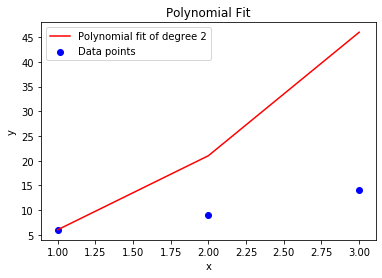

In [13]:
# Generate predicted y-values based on the fitted polynomial
y_pred = polynomial(x)
# Step 4: Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()